In [1]:
#Load the csv dataset files
import pandas as pd
Links=pd.read_csv(r"C:\Users\T2Gic\Downloads\archive (2)\links.csv") 
Movies=pd.read_csv(r"C:\Users\T2Gic\Downloads\archive (2)\movies.csv")
Ratings=pd.read_csv(r"C:\Users\T2Gic\Downloads\archive (2)\ratings.csv")
Tags=pd.read_csv(r"C:\Users\T2Gic\Downloads\archive (2)\tags.csv")

print('Files are imported successfully')

Files are imported successfully


In [2]:
#Check for numerical data in each file
numeric_columns = Links.select_dtypes(include='number').columns.tolist()
print("Numerical columns in Links:", numeric_columns)

numeric_columns = Movies.select_dtypes(include='number').columns.tolist()
print("Numerical columns in Movies:", numeric_columns)

numeric_columns = Ratings.select_dtypes(include='number').columns.tolist()
print("Numerical columns in Ratings :", numeric_columns)

numeric_columns = Tags.select_dtypes(include='number').columns.tolist()
print("Numerical columns in Tags:", numeric_columns)



Numerical columns in Links: ['movieId', 'imdbId', 'tmdbId']
Numerical columns in Movies: ['movieId']
Numerical columns in Ratings : ['userId', 'movieId', 'rating', 'timestamp']
Numerical columns in Tags: ['userId', 'movieId', 'timestamp']


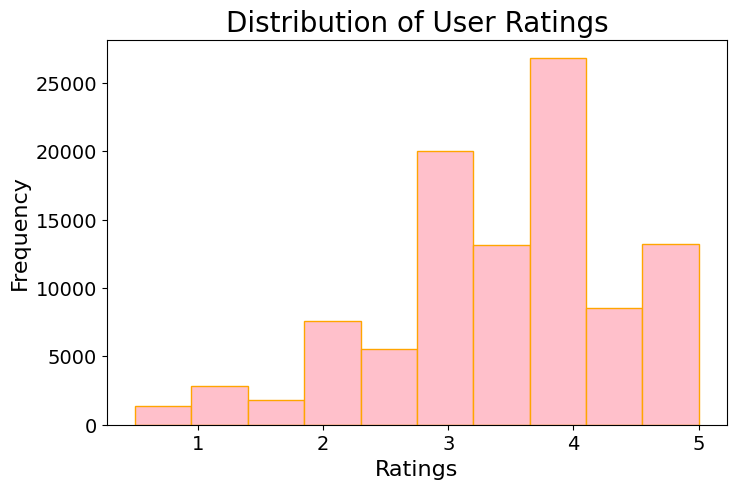

In [3]:
#Create Visualizations
#Using Matplotlib
#  Histogram- How users rate movies
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(Ratings['rating'], bins=10, color='pink', edgecolor='orange')
plt.title('Distribution of User Ratings',fontsize=20)
plt.xlabel('Ratings',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(False)#Did not want gridlines in the visualization
plt.show()

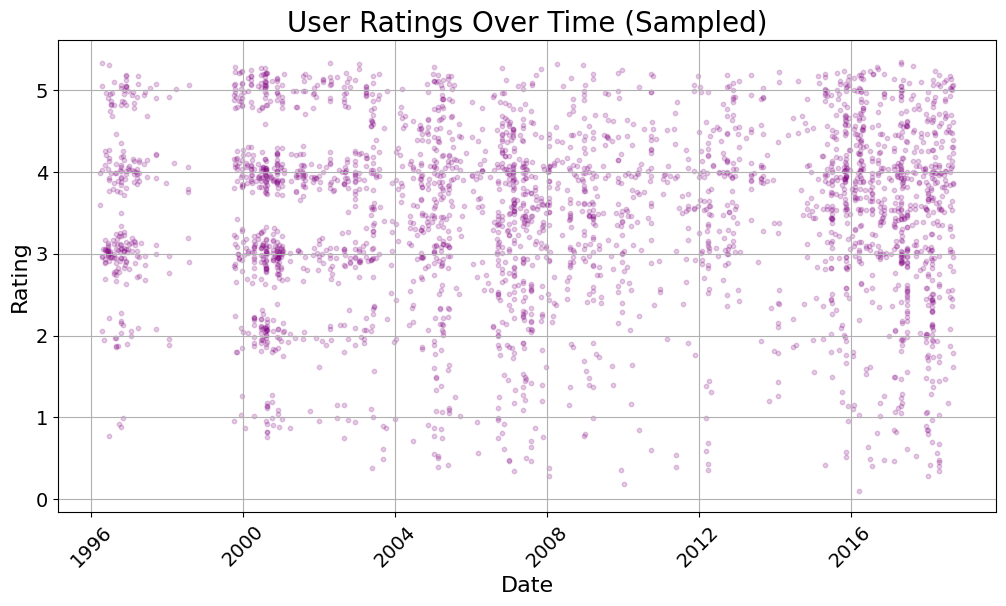

In [4]:
#Scatterplot- How user ratings vary over time
#For accuracy I used a sample of the dataset
import matplotlib.pyplot as plt

# Step 1: Sample the dataset (adjust n as needed)
sampled = Ratings.sample(n=3000, random_state=42)

# Step 2: Convert timestamp to datetime
import pandas as pd
sampled['datetime'] = pd.to_datetime(sampled['timestamp'], unit='s')

# Step 3: Add jitter to ratings
import numpy as np
sampled['rating_jittered'] = sampled['rating'] + np.random.normal(0, 0.15, size=len(sampled))

# Step 4: Plot the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(sampled['datetime'], sampled['rating_jittered'], alpha=0.2, s=10, color='purple')
plt.title('User Ratings Over Time (Sampled)',fontsize=20)
plt.xlabel('Date',fontsize=16)
plt.ylabel('Rating',fontsize=16)
plt.xticks(rotation=45,fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout(pad=0.5)
plt.show()

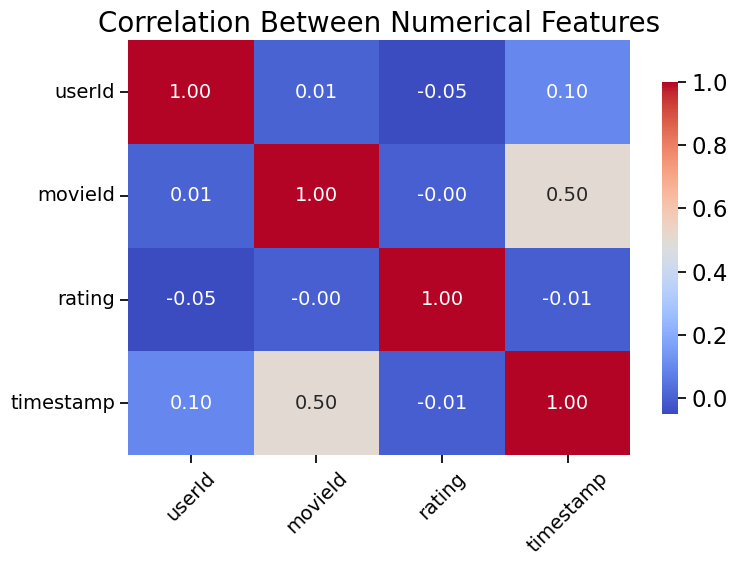

In [5]:
#Seaborn Heatmap — Correlation Matrix
#Identify which features are mostly related
#Output shows its movieId and timestamp

#Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

#Correlation matrix
corr_matrix = Ratings[['userId', 'movieId', 'rating', 'timestamp']].corr()

#Set figure size and font scale
plt.figure(figsize=(8, 6))
sns.set_context("notebook", font_scale=1.5)

#Draw heatmap with bigger annotation text
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            annot_kws={"size": 14},  # Font size for values inside cells
            cbar_kws={"shrink": 0.8})  # Optional: shrink color bar

#Customize axis labels
plt.title('Correlation Between Numerical Features',fontsize=20)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
plt.show()
